# BAI2063 Artificial Intelligence Applications
## Credit Card Fraud Detection - Finance Domain

This notebook implements the code required for:

- **Task A1:** dataset acquisition, data-quality analysis, EDA and preprocessing
- **Task A2:** tuned Logistic Regression and Random Forest baselines
- **Task B:** an Artificial Neural Network (ANN), learning curves and model comparison

**Dataset:** [Credit Card Fraud Detection (ULB/Kaggle)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

Download `creditcard.csv` and place it in the same folder as this notebook. The target is `Class`, where 0 represents a legitimate transaction and 1 represents fraud. `V1`-`V28` are anonymised PCA components; `Time` and `Amount` are the remaining numerical features.

Recommended environment: Python 3.10+, pandas, NumPy, Matplotlib, Seaborn, scikit-learn, imbalanced-learn and TensorFlow 2.x.

---
## 1. Setup and reproducibility

Fixed random seeds are used throughout. TensorFlow deterministic operations are enabled when supported by the runtime.

In [1]:
import random
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import imblearn
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

sns.set_theme(style="whitegrid")

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"imbalanced-learn: {imblearn.__version__}")
print(f"TensorFlow: {tf.__version__}")

Python: 3.13.9
pandas: 3.0.2
scikit-learn: 1.7.2
imbalanced-learn: 0.14.0
TensorFlow: 2.21.0


---
## 2. Data loading and data-quality analysis

The dataset contains only numerical features, so categorical encoding is not required. Missing values and exact duplicate rows are checked before modelling. Exact duplicates are removed to reduce the risk that identical observations appear in different data splits and inflate evaluation results.

In [2]:
df = pd.read_csv("creditcard.csv")
print(f"Original dataset shape: {df.shape}")
df.head()

Original dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("=== Data types and non-null counts ===")
df.info()

print("\n=== Descriptive statistics ===")
df.describe().T

=== Data types and non-null counts ===
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-n

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [4]:
missing_counts = df.isna().sum()
duplicate_count = int(df.duplicated().sum())

print(f"Total missing values: {int(missing_counts.sum()):,}")
print(f"Exact duplicate rows: {duplicate_count:,} ({duplicate_count / len(df) * 100:.2f}%)")

if missing_counts.sum() > 0:
    display(missing_counts[missing_counts > 0].sort_values(ascending=False))

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after duplicate removal: {df.shape}")
print(df["Class"].value_counts())
print(f"Fraud rate after cleaning: {df['Class'].mean() * 100:.3f}%")

Total missing values: 0
Exact duplicate rows: 1,081 (0.38%)
Shape after duplicate removal: (283726, 31)
Class
0    283253
1       473
Name: count, dtype: int64
Fraud rate after cleaning: 0.167%


### Data-quality decision

There are no categorical variables to encode. If missing values are found in a different copy of the dataset, they should be investigated rather than silently removed. In the standard ULB dataset, no missing values are expected. Exact duplicate rows are removed before splitting.

---
## 3. Exploratory Data Analysis (EDA)

EDA examines the target imbalance, transaction amounts, time patterns, correlations and potential amount outliers.

,Count,Percentage (%)
Class,,
0,283253,99.833
1,473,0.167


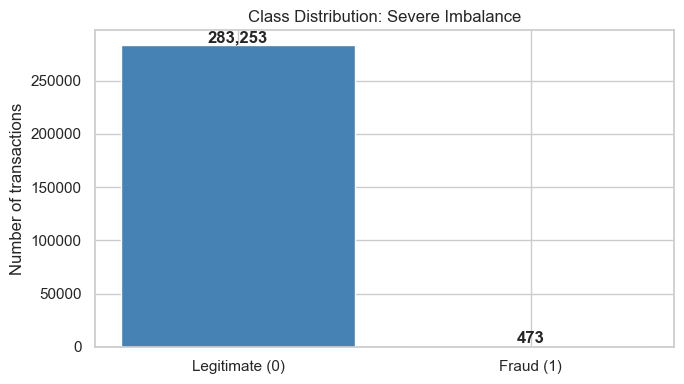

In [5]:
class_counts = df["Class"].value_counts().sort_index()
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100
class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percentages.round(3),
})
display(class_summary)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Legitimate (0)", "Fraud (1)"], class_counts.values,
              color=["steelblue", "tomato"])
ax.set_title("Class Distribution: Severe Imbalance")
ax.set_ylabel("Number of transactions")
for bar, value in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value,
            f"{value:,}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()

Amount observations above the IQR upper bound: 31,685


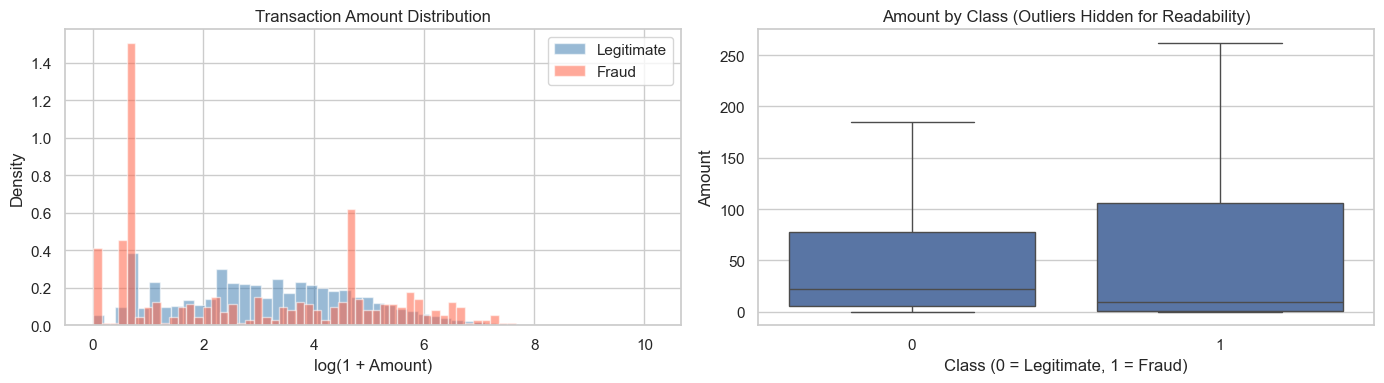

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for class_value, colour, label in [
    (0, "steelblue", "Legitimate"),
    (1, "tomato", "Fraud"),
]:
    values = np.log1p(df.loc[df["Class"] == class_value, "Amount"])
    axes[0].hist(values, bins=50, density=True, alpha=0.55,
                 color=colour, label=label)

axes[0].set_title("Transaction Amount Distribution")
axes[0].set_xlabel("log(1 + Amount)")
axes[0].set_ylabel("Density")
axes[0].legend()

sns.boxplot(data=df, x="Class", y="Amount", showfliers=False, ax=axes[1])
axes[1].set_title("Amount by Class (Outliers Hidden for Readability)")
axes[1].set_xlabel("Class (0 = Legitimate, 1 = Fraud)")

q1, q3 = df["Amount"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
amount_outliers = int((df["Amount"] > upper_bound).sum())
print(f"Amount observations above the IQR upper bound: {amount_outliers:,}")

plt.tight_layout()
plt.show()

,Absolute correlation with Class
V17,0.313498
V14,0.293375
V12,0.250711
V10,0.206971
V16,0.187186
V3,0.182322
V7,0.172347
V11,0.149067
V4,0.129326
V18,0.105340


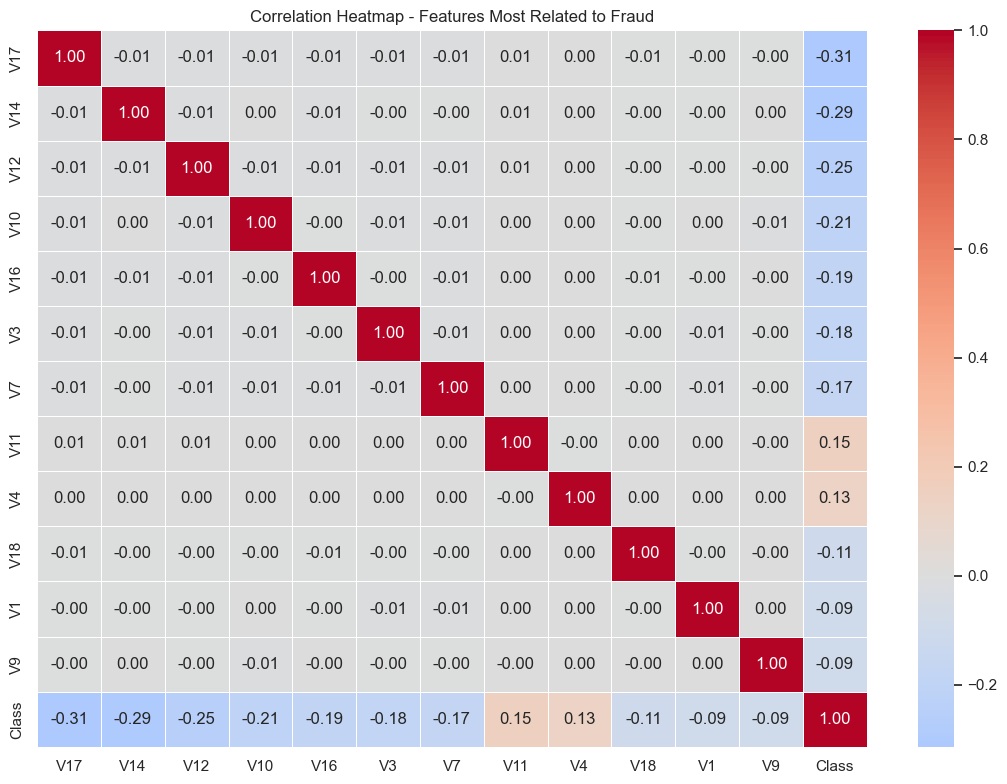

In [7]:
top_correlations = (
    df.corr(numeric_only=True)["Class"]
      .drop("Class")
      .abs()
      .sort_values(ascending=False)
      .head(12)
)
display(top_correlations.to_frame("Absolute correlation with Class"))

heatmap_columns = top_correlations.index.tolist() + ["Class"]
plt.figure(figsize=(11, 8))
sns.heatmap(
    df[heatmap_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
)
plt.title("Correlation Heatmap - Features Most Related to Fraud")
plt.tight_layout()
plt.show()

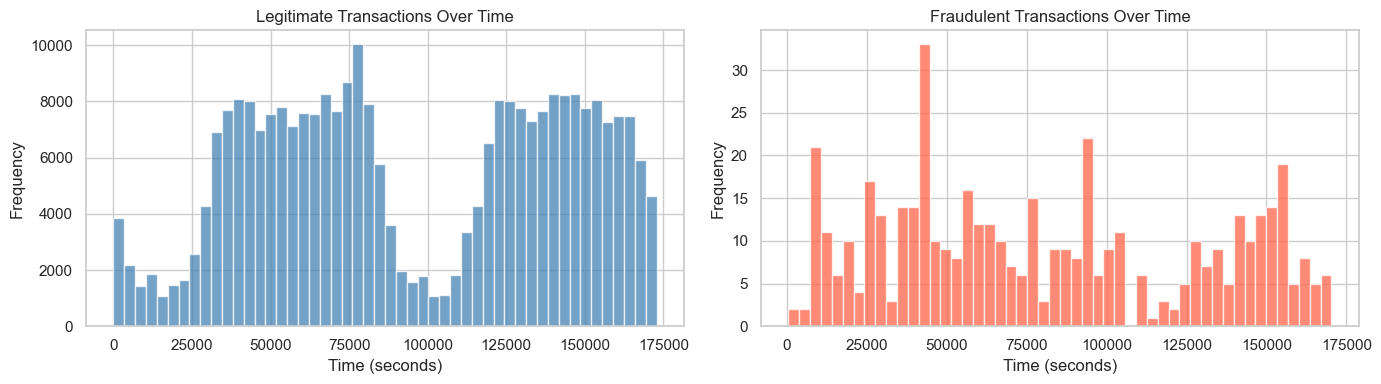

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.loc[df["Class"] == 0, "Time"].hist(
    bins=50, ax=axes[0], color="steelblue", alpha=0.75
)
axes[0].set_title("Legitimate Transactions Over Time")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Frequency")

df.loc[df["Class"] == 1, "Time"].hist(
    bins=50, ax=axes[1], color="tomato", alpha=0.75
)
axes[1].set_title("Fraudulent Transactions Over Time")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

---
## 4. Leakage-safe train/validation/test split

The data is split into 70% training, 15% validation and 15% test data using stratification because fraud is extremely rare. No scaler or resampling method is fitted before the split.

- Training data: model fitting and cross-validation
- Validation data: ANN early stopping and probability-threshold selection
- Test data: final unbiased evaluation only

In [9]:
X = df.drop(columns="Class")
y = df["Class"].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED,
)

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

for name, features, target in [
    ("Train", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test),
]:
    print(
        f"{name:10s}: {len(features):,} rows | "
        f"Fraud: {int(target.sum()):,} ({target.mean() * 100:.3f}%)"
    )

Train     : 198,608 rows | Fraud: 331 (0.167%)
Validation: 42,559 rows | Fraud: 71 (0.167%)
Test      : 42,559 rows | Fraud: 71 (0.167%)


### Classical-model preprocessing and imbalance strategy

Only `Amount` and `Time` require explicit standardisation because `V1`-`V28` are PCA-transformed features. Preprocessing and SMOTE are placed inside each cross-validation pipeline. This ensures that the scaler and synthetic observations are fitted only on the training portion of each fold.

SMOTE uses `sampling_strategy=0.10`: the minority class is increased to 10% of the majority class rather than forcing a 50/50 distribution. This reduces computational cost and avoids unnecessarily changing the training prior.

In [10]:
scale_columns = ["Amount", "Time"]

def make_preprocessor():
    return ColumnTransformer(
        transformers=[("scale", StandardScaler(), scale_columns)],
        remainder="passthrough",
        verbose_feature_names_out=False,
    )

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

print("Preprocessing and CV configuration created successfully.")

Preprocessing and CV configuration created successfully.


---
## 5. Task A2 - Classical supervised-learning baselines

### Model 1: Logistic Regression

Logistic Regression is an interpretable linear baseline. `C` controls regularisation strength, while the solver is tuned through stratified cross-validation. PR-AUC is used to select the best model because it focuses on minority-class retrieval under severe imbalance.

In [11]:
lr_pipeline = ImbPipeline(steps=[
    ("preprocess", make_preprocessor()),
    ("smote", SMOTE(sampling_strategy=0.10, random_state=SEED)),
    ("model", LogisticRegression(max_iter=2000, random_state=SEED)),
])

lr_parameters = {
    "model__C": [0.01, 0.1, 1.0, 10.0],
    "model__solver": ["lbfgs", "liblinear"],
}

lr_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_parameters,
    scoring=scoring,
    refit="pr_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)

lr_search.fit(X_train, y_train)
lr_best = lr_search.best_estimator_

print(f"Best Logistic Regression parameters: {lr_search.best_params_}")
print(f"Best CV PR-AUC: {lr_search.best_score_:.4f}")
best_lr_index = lr_search.best_index_
print(f"Corresponding CV ROC-AUC: {lr_search.cv_results_['mean_test_roc_auc'][best_lr_index]:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Logistic Regression parameters: {'model__C': 0.01, 'model__solver': 'liblinear'}
Best CV PR-AUC: 0.7560
Corresponding CV ROC-AUC: 0.9813


### Model 2: Random Forest

Random Forest captures nonlinear relationships and interactions that Logistic Regression may miss. A small `RandomizedSearchCV` is used instead of an exhaustive grid so the tuning remains practical on this large dataset.

In [12]:
rf_pipeline = ImbPipeline(steps=[
    ("preprocess", make_preprocessor()),
    ("smote", SMOTE(sampling_strategy=0.10, random_state=SEED)),
    ("model", RandomForestClassifier(
        random_state=SEED,
        n_jobs=1,
    )),
])

rf_parameters = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_parameters,
    n_iter=6,
    scoring=scoring,
    refit="pr_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)

rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_

print(f"Best Random Forest parameters: {rf_search.best_params_}")
print(f"Best CV PR-AUC: {rf_search.best_score_:.4f}")
best_rf_index = rf_search.best_index_
print(f"Corresponding CV ROC-AUC: {rf_search.cv_results_['mean_test_roc_auc'][best_rf_index]:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Random Forest parameters: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 12}
Best CV PR-AUC: 0.8446
Corresponding CV ROC-AUC: 0.9776


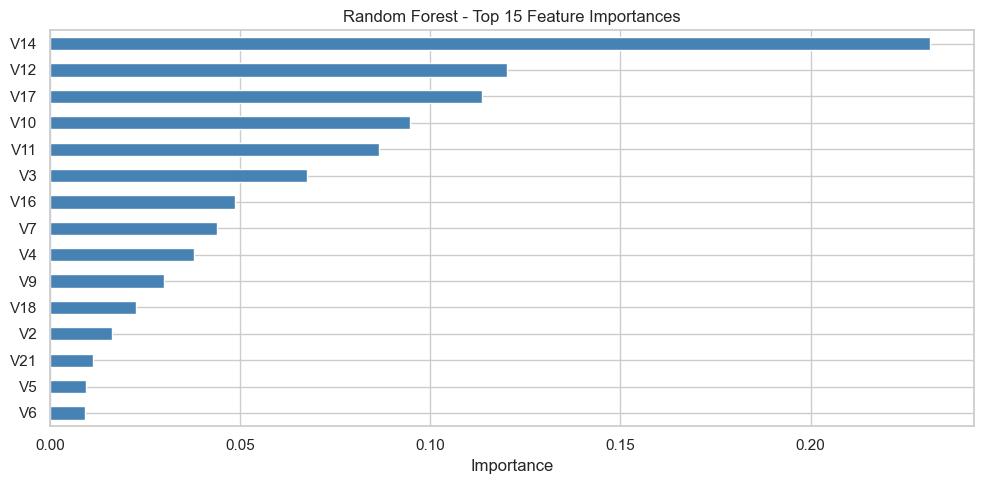

In [13]:
rf_feature_names = rf_best.named_steps["preprocess"].get_feature_names_out()
rf_importances = pd.Series(
    rf_best.named_steps["model"].feature_importances_,
    index=rf_feature_names,
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
rf_importances.sort_values().plot(kind="barh", color="steelblue")
plt.title("Random Forest - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

---
## 6. Task B - Artificial Neural Network

The ANN contains three progressively smaller dense layers. ReLU introduces nonlinearity, batch normalisation stabilises training, and dropout reduces overfitting. Binary cross-entropy and a sigmoid output are appropriate for binary classification.

For the ANN, class weighting is used instead of SMOTE. This keeps the original training observations and penalises mistakes on the rare fraud class more heavily. The validation set remains untouched and is used for early stopping.

In [14]:
ann_preprocessor = make_preprocessor()
X_train_ann = ann_preprocessor.fit_transform(X_train).astype("float32")
X_val_ann = ann_preprocessor.transform(X_val).astype("float32")
X_test_ann = ann_preprocessor.transform(X_test).astype("float32")

y_train_ann = y_train.to_numpy(dtype="float32")
y_val_ann = y_val.to_numpy(dtype="float32")
y_test_ann = y_test.to_numpy(dtype="int32")

class_values = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=class_values,
    y=y_train,
)
ann_class_weight = {int(cls): float(weight) for cls, weight in zip(class_values, weights)}

print(f"ANN input features: {X_train_ann.shape[1]}")
print(f"ANN class weights: {ann_class_weight}")

ANN input features: 30
ANN class weights: {0: 0.5008346908617742, 1: 300.012084592145}


In [15]:
def build_ann(input_dim, dropout_rate=0.30, learning_rate=1e-3):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(16, activation="relu"),
        Dropout(dropout_rate / 2),
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="roc_auc", curve="ROC"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        ],
    )
    return model

ann = build_ann(X_train_ann.shape[1])
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 192 (768.00 B)

In [16]:
callbacks = [
    EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = ann.fit(
    X_train_ann,
    y_train_ann,
    validation_data=(X_val_ann, y_val_ann),
    epochs=50,
    batch_size=512,
    class_weight=ann_class_weight,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8027 - loss: 0.3398 - pr_auc: 0.2691 - precision: 0.0074 - recall: 0.8761 - roc_auc: 0.9317 - val_accuracy: 0.9830 - val_loss: 0.1567 - val_pr_auc: 0.6638 - val_precision: 0.0797 - val_recall: 0.8732 - val_roc_auc: 0.9617 - learning_rate: 0.0010
Epoch 2/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9430 - loss: 0.2114 - pr_auc: 0.4386 - precision: 0.0253 - recall: 0.8852 - roc_auc: 0.9660 - val_accuracy: 0.9822 - val_loss: 0.1131 - val_pr_auc: 0.7066 - val_precision: 0.0775 - val_recall: 0.8873 - val_roc_auc: 0.9766 - learning_rate: 0.0010
Epoch 3/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9562 - loss: 0.1871 - pr_auc: 0.4844 - precision: 0.0331 - recall: 0.8973 - roc_auc: 0.9734 - val_accuracy: 0.9821 - val_loss: 0.0959 - val_pr_auc: 0.7238 - val_precision: 0.0772 - val_recall: 0.8873 - val_roc_auc: 0.9717 - learning_rate: 0.0010
Epoch 4/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 

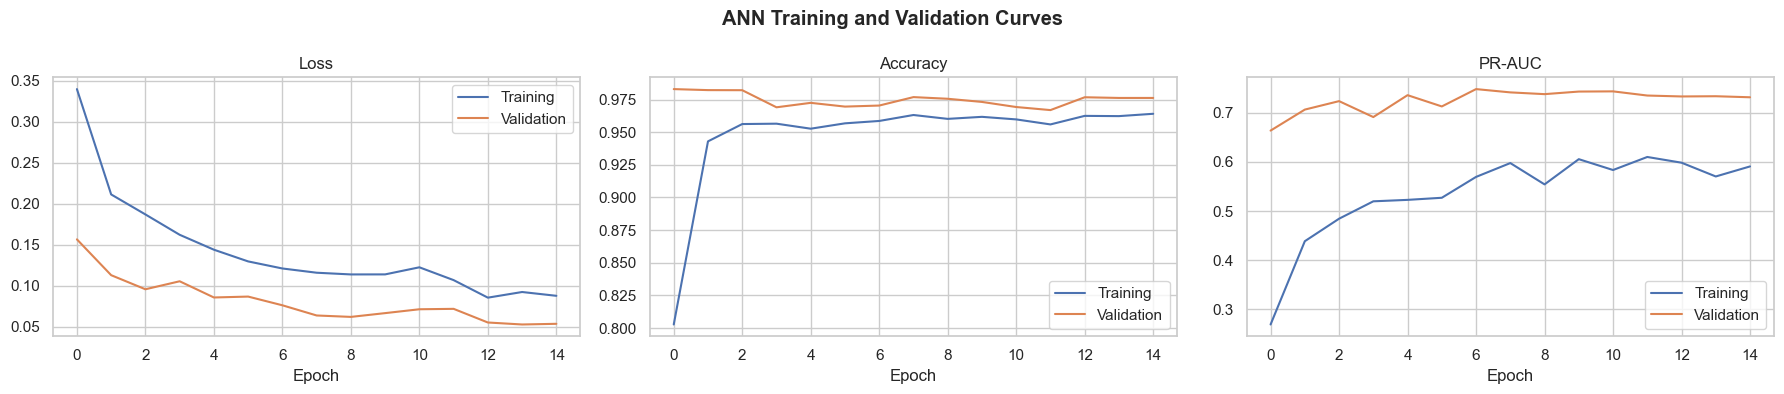

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history.history["loss"], label="Training")
axes[0].plot(history.history["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Training")
axes[1].plot(history.history["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history.history["pr_auc"], label="Training")
axes[2].plot(history.history["val_pr_auc"], label="Validation")
axes[2].set_title("PR-AUC")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.suptitle("ANN Training and Validation Curves", fontweight="bold")
plt.tight_layout()
plt.show()

### Interpreting the learning curves

After running the notebook, discuss the observed curves rather than making assumptions:

- A growing gap where training improves but validation worsens indicates overfitting.
- Poor performance on both sets indicates underfitting.
- Early stopping restores the weights from the epoch with the best validation PR-AUC.
- State the epoch at which training stopped and whether dropout/early stopping controlled overfitting.

---
## 7. Validation-based probability-threshold selection

The default threshold of 0.5 may be unsuitable for severe class imbalance. Thresholds are selected using validation data only. The selected thresholds are then applied once to the test set, preserving the test set as an unbiased final evaluation.

This notebook selects the threshold with the highest validation F1-score. In a real bank, the objective could instead impose a minimum recall or use explicit monetary costs.

In [18]:
def probability_outputs(model, X_data, keras_model=False):
    if keras_model:
        return model.predict(X_data, verbose=0).ravel()
    return model.predict_proba(X_data)[:, 1]


lr_val_proba = probability_outputs(lr_best, X_val)
lr_test_proba = probability_outputs(lr_best, X_test)

rf_val_proba = probability_outputs(rf_best, X_val)
rf_test_proba = probability_outputs(rf_best, X_test)

ann_val_proba = probability_outputs(ann, X_val_ann, keras_model=True)
ann_test_proba = probability_outputs(ann, X_test_ann, keras_model=True)

validation_probabilities = {
    "Logistic Regression": lr_val_proba,
    "Random Forest": rf_val_proba,
    "ANN": ann_val_proba,
}

test_probabilities = {
    "Logistic Regression": lr_test_proba,
    "Random Forest": rf_test_proba,
    "ANN": ann_test_proba,
}

print("Validation and test probabilities generated for all models.")

Validation and test probabilities generated for all models.


In [19]:
threshold_grid = np.arange(0.01, 1.00, 0.01)

def threshold_sweep(y_true, probabilities, thresholds):
    rows = []
    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)
        rows.append({
            "Threshold": float(threshold),
            "Precision": precision_score(y_true, predictions, zero_division=0),
            "Recall": recall_score(y_true, predictions, zero_division=0),
            "F1": f1_score(y_true, predictions, zero_division=0),
        })
    return pd.DataFrame(rows)


threshold_tables = {}
selected_thresholds = {}

for model_name, probabilities in validation_probabilities.items():
    table = threshold_sweep(y_val, probabilities, threshold_grid)
    threshold_tables[model_name] = table
    selected_thresholds[model_name] = float(
        table.loc[table["F1"].idxmax(), "Threshold"]
    )

pd.Series(selected_thresholds, name="Validation-selected threshold").to_frame()

,Validation-selected threshold
Logistic Regression,0.89
Random Forest,0.48
ANN,0.99


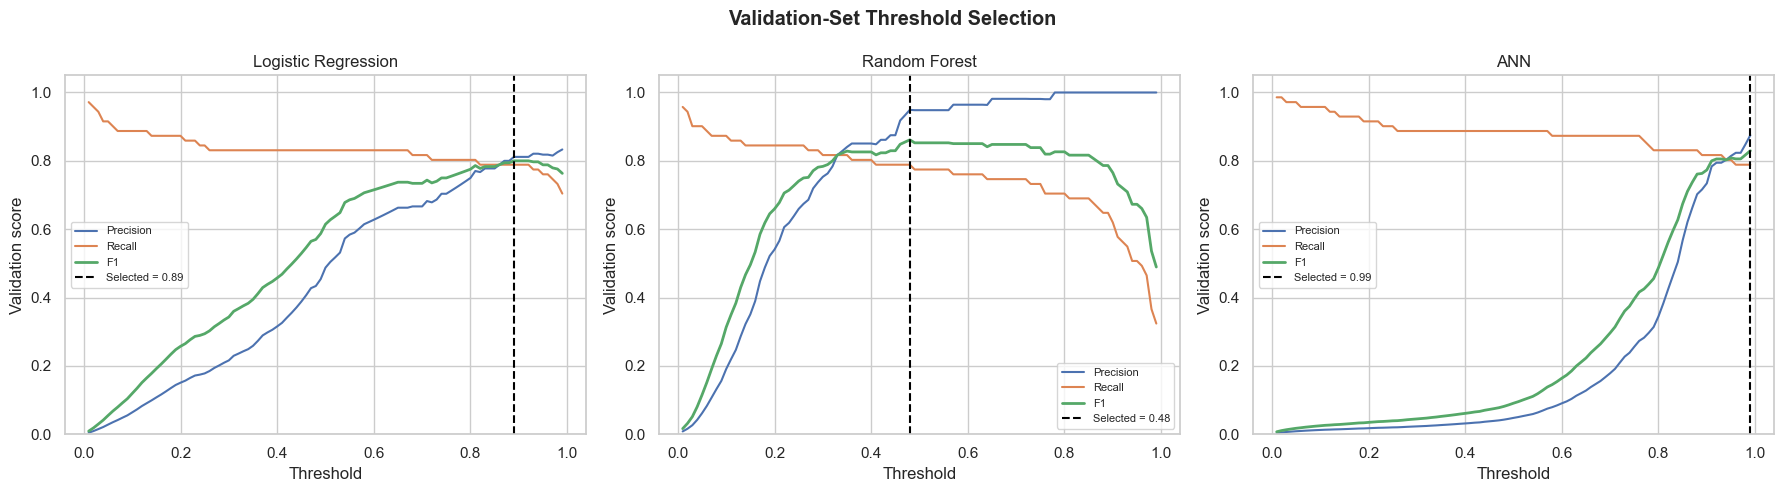

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, table) in zip(axes, threshold_tables.items()):
    selected = selected_thresholds[model_name]
    ax.plot(table["Threshold"], table["Precision"], label="Precision")
    ax.plot(table["Threshold"], table["Recall"], label="Recall")
    ax.plot(table["Threshold"], table["F1"], label="F1", linewidth=2)
    ax.axvline(selected, color="black", linestyle="--",
               label=f"Selected = {selected:.2f}")
    ax.set_title(model_name)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Validation score")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

plt.suptitle("Validation-Set Threshold Selection", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 8. Final test evaluation and model comparison

All models are evaluated on the same untouched test set using accuracy, fraud precision, fraud recall, fraud F1, ROC-AUC and PR-AUC. Confusion matrices use thresholds selected on the validation set.

In [21]:
def calculate_metrics(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    metrics = {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision (Fraud)": precision_score(y_true, predictions, zero_division=0),
        "Recall (Fraud)": recall_score(y_true, predictions, zero_division=0),
        "F1 (Fraud)": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "PR-AUC": average_precision_score(y_true, probabilities),
    }
    return metrics, predictions


default_results = {}
selected_results = {}
selected_predictions = {}

for model_name, probabilities in test_probabilities.items():
    default_results[model_name], _ = calculate_metrics(
        y_test, probabilities, threshold=0.50
    )
    selected_results[model_name], selected_predictions[model_name] = calculate_metrics(
        y_test, probabilities, threshold=selected_thresholds[model_name]
    )

default_results_df = pd.DataFrame(default_results).T
selected_results_df = pd.DataFrame(selected_results).T

print("=== Test results at default threshold 0.50 ===")
display(default_results_df.round(4))

print("=== Test results at validation-selected thresholds ===")
display(selected_results_df.round(4))

selected_results_df.to_csv("model_comparison_validation_thresholds.csv")

=== Test results at default threshold 0.50 ===


,Threshold,Accuracy,Precision (Fraud),Recall (Fraud),F1 (Fraud),ROC-AUC,PR-AUC
Logistic Regression,0.5,0.9980,0.4531,0.8169,0.5829,0.9641,0.7061
Random Forest,0.5,0.9994,0.8462,0.7746,0.8088,0.9791,0.7840
ANN,0.5,0.9722,0.0508,0.8873,0.0962,0.9600,0.6796


=== Test results at validation-selected thresholds ===


,Threshold,Accuracy,Precision (Fraud),Recall (Fraud),F1 (Fraud),ROC-AUC,PR-AUC
Logistic Regression,0.89,0.9992,0.7432,0.7746,0.7586,0.9641,0.7061
Random Forest,0.48,0.9994,0.8333,0.7746,0.8029,0.9791,0.7840
ANN,0.99,0.9993,0.8000,0.7887,0.7943,0.9600,0.6796



Logistic Regression - threshold 0.89
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42488
       Fraud       0.74      0.77      0.76        71

    accuracy                           1.00     42559
   macro avg       0.87      0.89      0.88     42559
weighted avg       1.00      1.00      1.00     42559



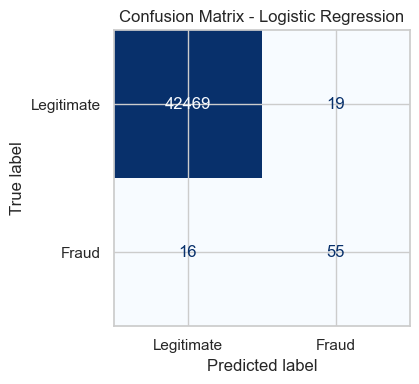


Random Forest - threshold 0.48
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42488
       Fraud       0.83      0.77      0.80        71

    accuracy                           1.00     42559
   macro avg       0.92      0.89      0.90     42559
weighted avg       1.00      1.00      1.00     42559



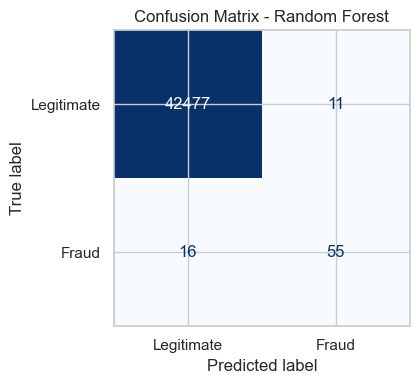


ANN - threshold 0.99
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42488
       Fraud       0.80      0.79      0.79        71

    accuracy                           1.00     42559
   macro avg       0.90      0.89      0.90     42559
weighted avg       1.00      1.00      1.00     42559



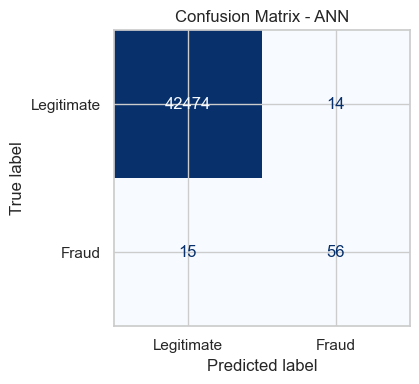

In [22]:
for model_name, predictions in selected_predictions.items():
    print("\n" + "=" * 70)
    print(f"{model_name} - threshold {selected_thresholds[model_name]:.2f}")
    print("=" * 70)
    print(classification_report(
        y_test,
        predictions,
        target_names=["Legitimate", "Fraud"],
        zero_division=0,
    ))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["Legitimate", "Fraud"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

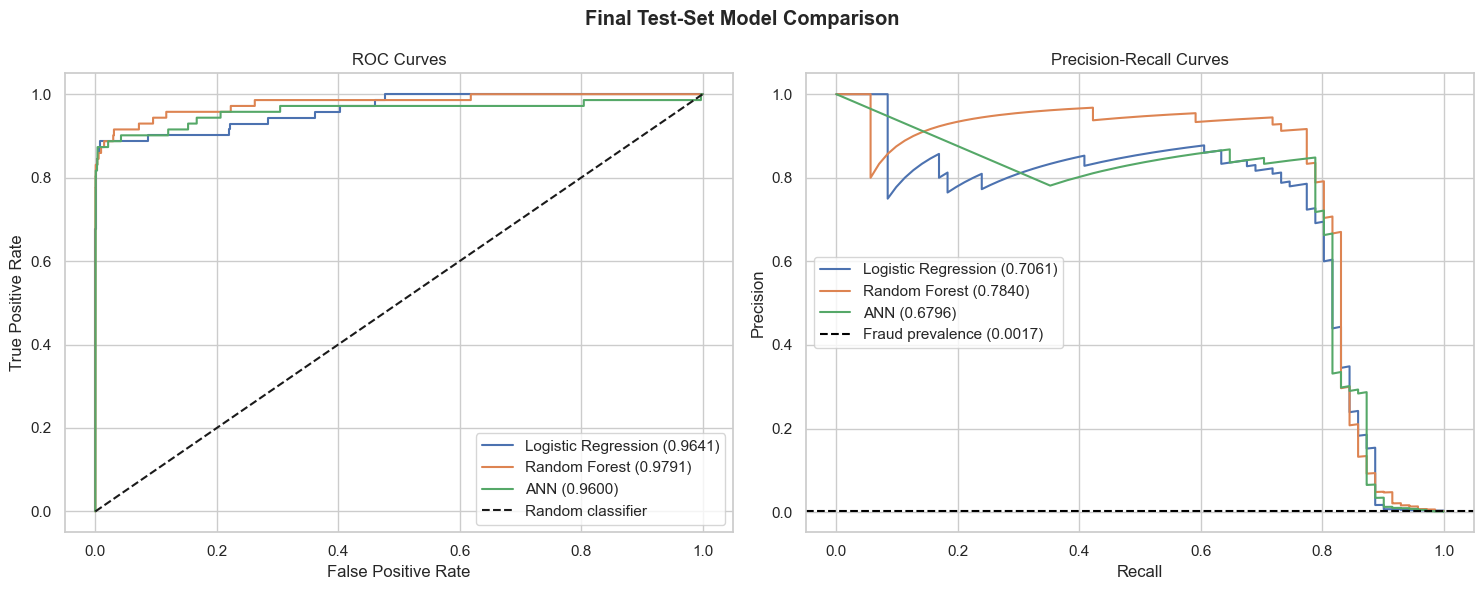

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for model_name, probabilities in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    roc_auc = roc_auc_score(y_test, probabilities)
    axes[0].plot(fpr, tpr, label=f"{model_name} ({roc_auc:.4f})")

    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    pr_auc = average_precision_score(y_test, probabilities)
    axes[1].plot(recall, precision, label=f"{model_name} ({pr_auc:.4f})")

axes[0].plot([0, 1], [0, 1], "k--", label="Random classifier")
axes[0].set_title("ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

baseline = y_test.mean()
axes[1].axhline(baseline, color="black", linestyle="--",
                label=f"Fraud prevalence ({baseline:.4f})")
axes[1].set_title("Precision-Recall Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.suptitle("Final Test-Set Model Comparison", fontweight="bold")
plt.tight_layout()
plt.show()

### Statistical uncertainty

The test set contains relatively few fraud observations, so single metric estimates may vary with the sampled transactions. The following stratified bootstrap reports 95% confidence intervals for threshold-independent ROC-AUC and PR-AUC.

In [24]:
def stratified_bootstrap_auc(y_true, probabilities, n_bootstrap=500, seed=SEED):
    y_array = np.asarray(y_true)
    probabilities = np.asarray(probabilities)
    negative_indices = np.flatnonzero(y_array == 0)
    positive_indices = np.flatnonzero(y_array == 1)
    rng = np.random.default_rng(seed)

    roc_scores = []
    pr_scores = []
    for _ in range(n_bootstrap):
        sampled_negative = rng.choice(
            negative_indices, size=len(negative_indices), replace=True
        )
        sampled_positive = rng.choice(
            positive_indices, size=len(positive_indices), replace=True
        )
        sampled = np.concatenate([sampled_negative, sampled_positive])
        roc_scores.append(roc_auc_score(y_array[sampled], probabilities[sampled]))
        pr_scores.append(average_precision_score(
            y_array[sampled], probabilities[sampled]
        ))

    return {
        "ROC-AUC 95% CI": tuple(np.quantile(roc_scores, [0.025, 0.975]).round(4)),
        "PR-AUC 95% CI": tuple(np.quantile(pr_scores, [0.025, 0.975]).round(4)),
    }


confidence_intervals = {
    model_name: stratified_bootstrap_auc(y_test, probabilities)
    for model_name, probabilities in test_probabilities.items()
}

pd.DataFrame(confidence_intervals).T

,ROC-AUC 95% CI,PR-AUC 95% CI
Logistic Regression,"(0.9355, 0.9864)","(0.6022, 0.8239)"
Random Forest,"(0.9542, 0.9943)","(0.6624, 0.8893)"
ANN,"(0.9184, 0.9911)","(0.5712, 0.8031)"


---
## 9. Final analysis checklist for the technical report

After running all cells, use the actual outputs to discuss:

1. Which model achieved the highest test PR-AUC and whether its confidence interval overlaps those of the alternatives.
2. Which model achieved the best fraud F1-score at its validation-selected threshold.
3. The false-positive versus false-negative trade-off shown by each confusion matrix.
4. Whether the ANN learning curves indicate overfitting or underfitting.
5. Whether the ANN's additional complexity produced a meaningful improvement over classical models.
6. Why accuracy is potentially misleading when fraud prevalence is approximately 0.17%.
7. Practical implications such as investigation workload, missed fraud, customer inconvenience and model monitoring.

Do not write that a model was “expected” to perform best. Base every conclusion on the generated metrics and figures.